In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("output/sima_2020_2025_limpio.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_PATH}. Ejecuta primero la Etapa 1."
    )

df = pd.read_parquet(DATA_PATH)
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

contaminantes = ["CO", "NO2", "O3", "PM10", "PM2.5"]
meteorologicas = ["TOUT", "RH", "SR", "WSR", "WDR", "RAINF", "PRS"]
variables_movilidad = ["año_archivo", "mes", "hora", "dia_semana", "es_fin_de_semana", "temporada"]
variables_categoricas = ["estación", "año_archivo", "mes", "hora", "dia_semana", "temporada", "es_fin_de_semana"]

print(f"Base cargada: {DATA_PATH}")
print(f"Registros: {len(df):,} | Columnas: {df.shape[1]}")
print("La base no incluye medición directa de tráfico vehicular; por ello se usará horario, día de la semana y temporada como aproximación de movilidad.")


Base cargada: output\sima_2020_2025_limpio.parquet
Registros: 688,184 | Columnas: 33
La base no incluye medición directa de tráfico vehicular; por ello se usará horario, día de la semana y temporada como aproximación de movilidad.


# ETAPA 2. Comprensión y preparación de los datos

## Contexto del proyecto y objetivo de análisis

La base contiene observaciones horarias de calidad del aire y variables meteorológicas en estaciones de monitoreo de la Zona Metropolitana de Monterrey. El enfoque del proyecto ya no está centrado en evaluar el efecto del Metro, sino en analizar cómo la combinación de condiciones meteorológicas y la actividad vehicular influye en la contaminación atmosférica.

El objetivo principal es estudiar la relación entre la contaminación del aire y las condiciones meteorológicas en Monterrey, con especial énfasis en la contaminación asociada al tráfico vehicular. Para ello, se analizará cómo variables como temperatura, humedad relativa, radiación solar, velocidad y dirección del viento, precipitación y estabilidad atmosférica se relacionan con la concentración de contaminantes como NO2, CO, PM2.5, PM10 y O3.

Además, se incorporarán variables temporales como horario, día de la semana, temporada del año y diferencias entre estaciones de monitoreo. Esto permitirá identificar patrones críticos de contaminación durante periodos de mayor actividad vehicular y bajo condiciones meteorológicas que favorecen la acumulación de contaminantes. En particular, se busca comparar horas pico versus horas de menor movilidad, así como temporadas secas versus de lluvias, y entender cómo estas condiciones influyen en la calidad del aire en la ZMM.

### Hipótesis de trabajo

La contaminación del aire en Monterrey presenta una fuerte variación temporal y espacial. Se espera que: 

- las horas de mayor actividad vehicular (mañana y tarde) presenten concentraciones más altas de NO2, CO y partículas;
- la velocidad del viento y la precipitación favorezcan la dispersión y lavado de contaminantes, reduciendo sus concentraciones;
- la humedad, la baja radiación solar y la estabilidad atmosférica pueden favorecer la acumulación de contaminantes, especialmente en periodos secos;
- las estaciones con mayor tránsito o más cercanas a zonas urbanizadas puedan mostrar niveles más altos de contaminación.

Este análisis alimentará el diseño de una página web final que, según la estación de monitoreo más cercana a la ubicación del usuario, muestre el estado actual de la calidad del aire y las condiciones meteorológicas asociadas. La herramienta usará horario y día de la semana como aproximación de la movilidad vehicular para indicar si el momento actual corresponde a hora pico o no pico, y si las condiciones históricas suelen asociarse con mayor o menor acumulación de contaminantes.

## Variables candidatas para el análisis

Para estudiar esta relación se consideran tres grupos principales:

- **Resultados ambientales:** `CO`, `NO2`, `O3`, `PM10`, `PM2.5`.
- **Condiciones meteorológicas:** temperatura (`TOUT`), humedad relativa (`RH`), radiación solar (`SR`), velocidad del viento (`WSR`), dirección del viento (`WDR`), precipitación (`RAINF`) y presión atmosférica (`PRS`).
- **Aproximaciones de movilidad y temporalidad:** hora del día, día de la semana, fin de semana, mes, temporada del año y estación de monitoreo.

La idea es usar estas variables para detectar patrones de acumulación de contaminantes en momentos y condiciones que favorecen la contaminación vehicular.


In [2]:
print("Dimensión del dataset")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Periodo: {df['fecha_hora'].min()} a {df['fecha_hora'].max()}")
print(f"Estaciones: {df['estación'].nunique()}")

descripcion_variables = pd.DataFrame(
    {
        "variable": [
            "fecha_hora", "CO", "NO2", "O3", "PM10", "PM2.5", "NO", "NOX",
            "PRS", "RAINF", "RH", "SO2", "SR", "TOUT", "WSR", "WDR",
            "estación", "año_archivo", "año", "mes", "hora", "dia_semana",
            "es_fin_de_semana", "temporada", "PM2.5_nivel_cuartil"
        ],
        "descripción": [
            "Fecha y hora de la medición", "Monóxido de carbono", "Dióxido de nitrógeno",
            "Ozono", "Partículas menores a 10 micrómetros", "Partículas menores a 2.5 micrómetros",
            "Óxido nítrico", "Óxidos de nitrógeno", "Presión atmosférica", "Precipitación",
            "Humedad relativa", "Dióxido de azufre", "Radiación solar", "Temperatura exterior",
            "Velocidad del viento", "Dirección del viento", "Estación de monitoreo",
            "Año del archivo fuente", "Año de la fecha", "Mes", "Hora del día",
            "Día de la semana", "Indicador de fin de semana", "Temporada del año",
            "Nivel de PM2.5 por cuartil"
        ],
        "tipo": [
            "Temporal", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
            "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
            "Numérico", "Numérico", "Numérico", "Numérico", "Categórico", "Numérico",
            "Numérico", "Numérico", "Numérico", "Numérico", "Categórico", "Categórico",
            "Categórico"
        ],
    }
)
descripcion_variables["valores_posibles"] = [
    df[col].dropna().unique()[:10].tolist() for col in descripcion_variables["variable"]
]
descripcion_variables["nulos"] = [df[col].isna().sum() for col in descripcion_variables["variable"]]
descripcion_variables["porcentaje_nulos"] = [df[col].isna().mean() * 100 for col in descripcion_variables["variable"]]
display(descripcion_variables)


Dimensión del dataset
Registros: 688,184
Columnas: 33
Periodo: 2020-01-01 00:00:00 a 2025-06-30 23:00:00
Estaciones: 15


,variable,descripción,tipo,valores_posibles,nulos,porcentaje_nulos
0,fecha_hora,Fecha y hora de la medición,Temporal,"[2020-01-01 00:00:00, 2020-01-01 01:00:00, 202...",0,0.00
1,CO,Monóxido de carbono,Numérico,"[3.28, 3.35, 3.22, 3.26, 3.25, 3.36, 3.4, 3.24...",81505,11.84
2,NO2,Dióxido de nitrógeno,Numérico,"[6.5, 5.6, 7.2, 10.6, 10.1, 9.5, 8.6, 8.5, 7.9...",109711,15.94
3,O3,Ozono,Numérico,"[19.0, 18.0, 14.0, 5.0, 3.0, 4.0, 6.0, 8.0, 9....",88618,12.88
4,PM10,Partículas menores a 10 micrómetros,Numérico,"[112.01, 100.01, 106.2, 141.86, 122.24, 113.71...",17992,2.61
5,PM2.5,Partículas menores a 2.5 micrómetros,Numérico,"[85.64, 72.39, 70.25, 93.72, 83.93, 77.28, 67....",131175,19.06
6,NO,Óxido nítrico,Numérico,"[3.3, 3.1, 3.2, 4.7, 5.0, 4.2, 4.0, 6.0, 6.1, ...",96946,14.09
7,NOX,Óxidos de nitrógeno,Numérico,"[9.8, 8.8, 10.4, 15.3, 15.1, 13.7, 12.5, 14.5,...",104318,15.16
8,PRS,Presión atmosférica,Numérico,"[713.6, 712.8, 712.4, 712.0, 711.9, 711.8, 711...",26056,3.79
9,RAINF,Precipitación,Numérico,"[0.0, 0.85, 0.04, 0.01, 0.54, 0.19, 0.31, 0.22...",27002,3.92


## Estadística descriptiva inicial

Se calculan medidas de tendencia central y dispersión para los contaminantes y las variables meteorológicas. El objetivo es identificar qué contaminantes presentan mayor variabilidad y qué condiciones climáticas parecen estar asociadas con la acumulación de partículas y gases.


In [3]:
def resumen_numerico(columnas):
    estadistica = []
    for variable in columnas:
        serie = df[variable].dropna()
        estadistica.append(
            {
                "variable": variable,
                "n_validos": serie.size,
                "promedio": serie.mean(),
                "mediana": serie.median(),
                "moda": serie.mode().tolist(),
                "mínimo": serie.min(),
                "máximo": serie.max(),
                "rango": serie.max() - serie.min(),
                "varianza": serie.var(),
                "desviación_estándar": serie.std(),
                "asimetría": serie.skew(),
            }
        )
    return pd.DataFrame(estadistica).set_index("variable")

print("Contaminantes principales")
display(resumen_numerico(contaminantes))
print("Variables meteorológicas")
display(resumen_numerico(meteorologicas))


Contaminantes principales


,n_validos,promedio,mediana,moda,mínimo,máximo,rango,varianza,desviación_estándar,asimetría
variable,,,,,,,,,,
CO,606679,1.38,1.23,[0.7],0.00,37.00,37.00,0.77,0.88,1.72
NO2,578473,14.36,11.20,[0.5],0.00,188.60,188.60,130.56,11.43,2.02
O3,599566,26.77,23.00,[16.0],0.50,265.00,264.50,359.33,18.96,1.29
PM10,670192,59.14,50.00,[39.0],1.00,1001.00,1000.00,1749.49,41.83,3.97
PM2.5,557009,20.54,17.00,[10.0],0.00,999.00,999.00,250.14,15.82,5.63


Variables meteorológicas


,n_validos,promedio,mediana,moda,mínimo,máximo,rango,varianza,desviación_estándar,asimetría
variable,,,,,,,,,,
TOUT,651852,23.01,23.89,[24.4],-9999.00,785.00,10784.00,1033.39,32.15,-279.47
RH,625616,56.79,59.00,[77.0],0.00,100.00,100.00,454.68,21.32,-0.33
SR,669910,-0.03,0.01,[0.0],-9999.00,501.00,10500.00,1725.06,41.53,-236.05
WSR,652775,8.39,7.40,[1.4],0.10,227.10,227.00,43.59,6.60,7.02
WDR,640155,140.31,116.00,[105.0],1.00,360.00,359.00,8925.97,94.48,0.76
RAINF,661182,0.02,0.00,[0.0],0.00,360.00,360.00,1.11,1.05,249.01
PRS,662128,715.22,714.30,[729.0],0.00,750.00,750.00,91.70,9.58,-0.58


## Variables cualitativas y patrones temporales

Las tablas de frecuencia permiten visualizar la distribución de la contaminación según estación de monitoreo, temporada, hora y día de la semana. Estas variables son clave porque el tráfico y la meteorología no son homogéneos a lo largo del día ni del año.


In [4]:
for variable in variables_categoricas:
    frecuencia = (
        df[variable]
        .value_counts(dropna=False)
        .rename_axis(variable)
        .reset_index(name="frecuencia")
    )
    frecuencia["porcentaje"] = frecuencia["frecuencia"] / len(df) * 100
    print(f"Distribución de {variable}")
    display(frecuencia)

nivel_ordinal = df["PM2.5_nivel_cuartil"].dropna()
if isinstance(nivel_ordinal.dtype, pd.CategoricalDtype):
    codigos = nivel_ordinal.cat.codes
    codigo_mediano = int(round(codigos.median()))
    mediana_ordinal = nivel_ordinal.cat.categories[codigo_mediano]
else:
    mediana_ordinal = nivel_ordinal.median()
print("Mediana ordinal de PM2.5_nivel_cuartil, como indicador complementario:")
print(mediana_ordinal)


Distribución de estación


,estación,frecuencia,porcentaje
0,CE,48190,7.00
1,SE,48183,7.00
2,NO,48181,7.00
3,NE,48180,7.00
4,NTE,48180,7.00
5,NO2,48179,7.00
6,SE2,48179,7.00
7,NTE2,48178,7.00
8,SE3,48178,7.00
9,SO2,48178,7.00


Distribución de año_archivo


,año_archivo,frecuencia,porcentaje
0,2024,131741,19.14
1,2023,131370,19.09
2,2022,123383,17.93
3,2021,122629,17.82
4,2020,114102,16.58
5,2025,64959,9.44


Distribución de mes


...

Distribución de temporada


,temporada,frecuencia,porcentaje
0,lluvias,271464,39.45
1,seca-fria,226898,32.97
2,seca-calida,189822,27.58


Distribución de es_fin_de_semana


,es_fin_de_semana,frecuencia,porcentaje
0,False,491428,71.41
1,True,196756,28.59


Mediana ordinal de PM2.5_nivel_cuartil, como indicador complementario:
medio


## Exploración visual orientada al objetivo

Se usarán gráficos de dispersión, boxplots y perfiles horarios para detectar patrones de contaminación asociados con el tráfico y con condiciones meteorológicas. La intuición clave es que la contaminación no responde solo a emisiones, sino también a la capacidad del ambiente para dispersarlas o atraparlas.


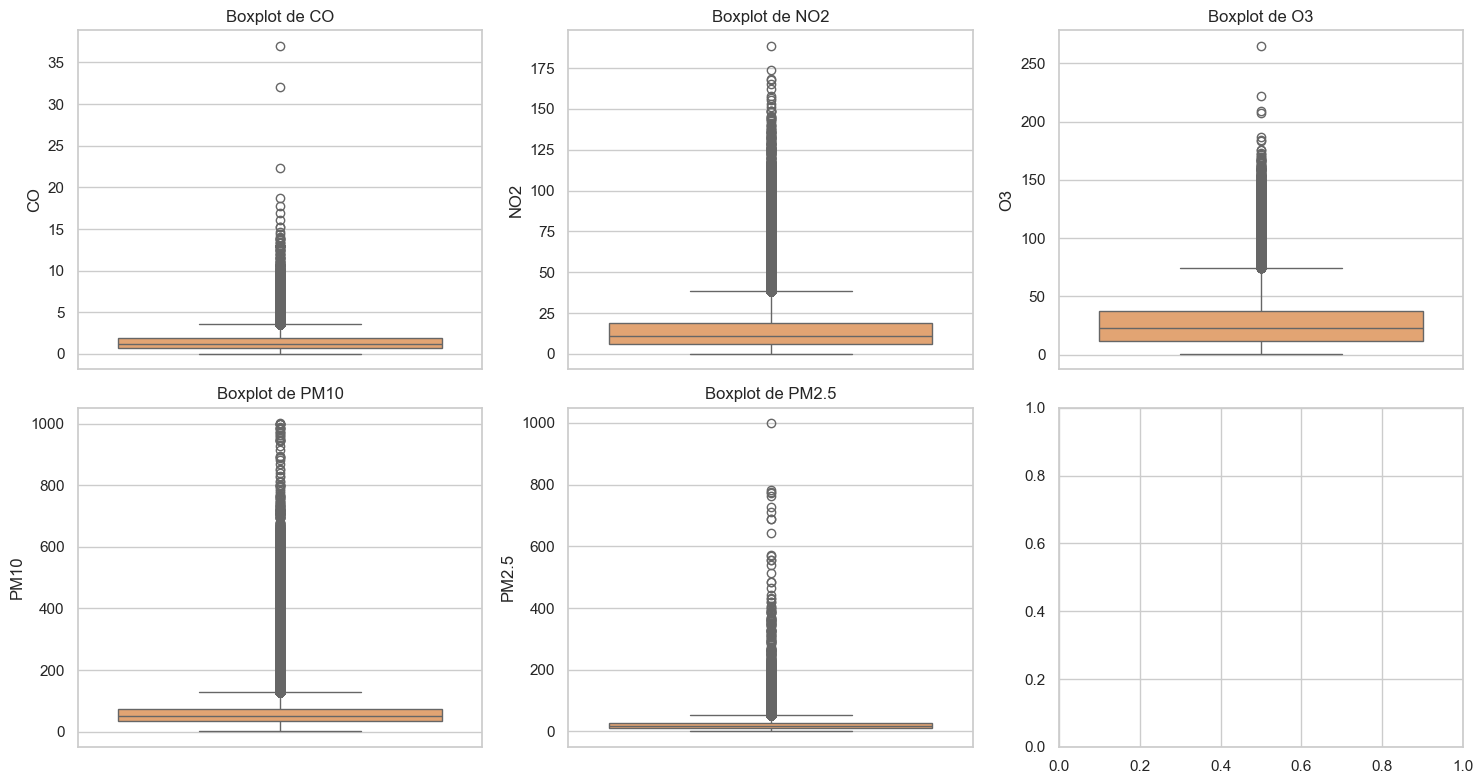

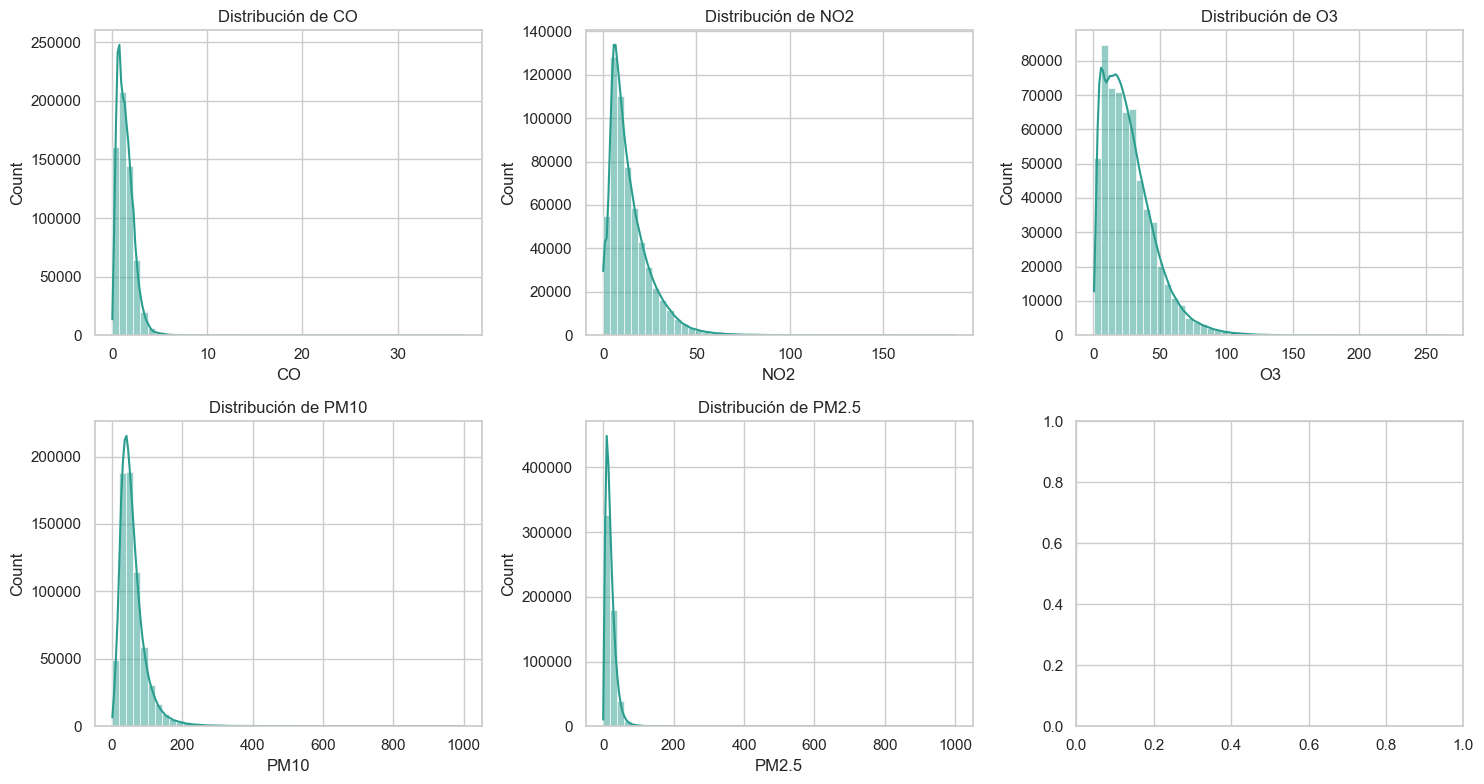

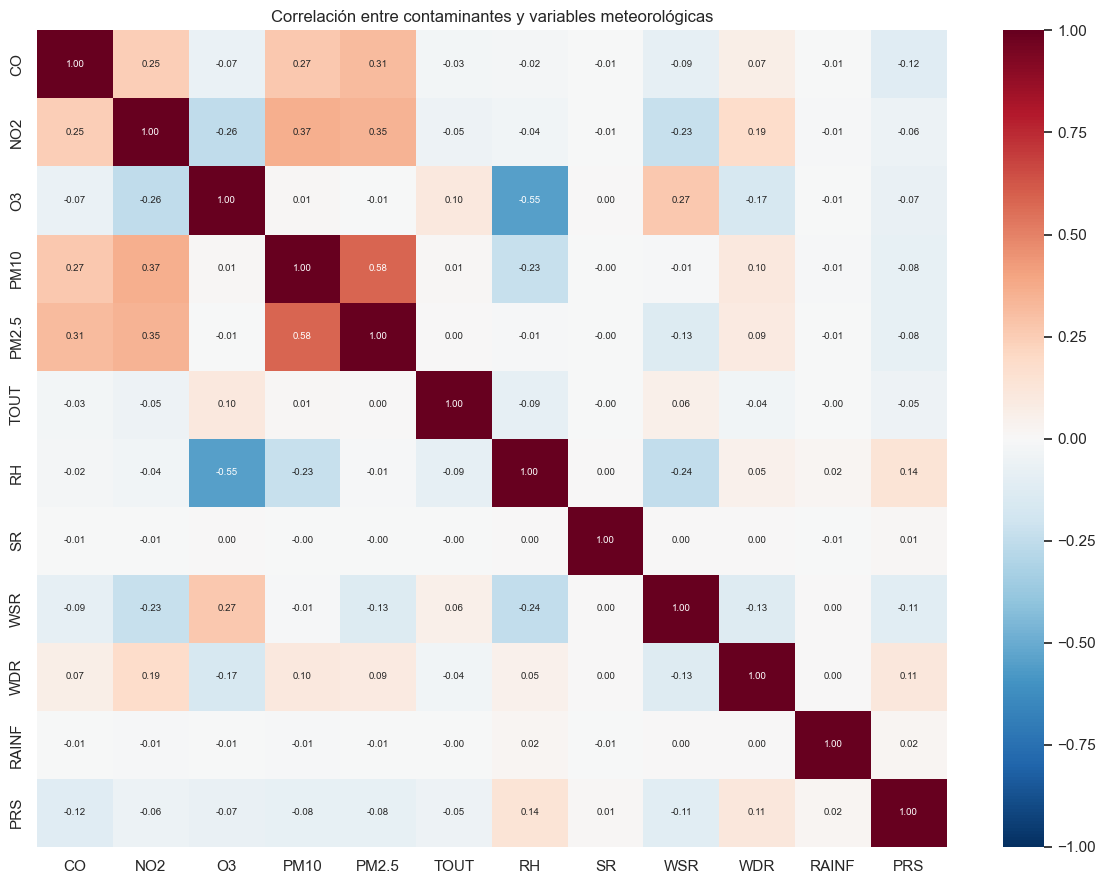

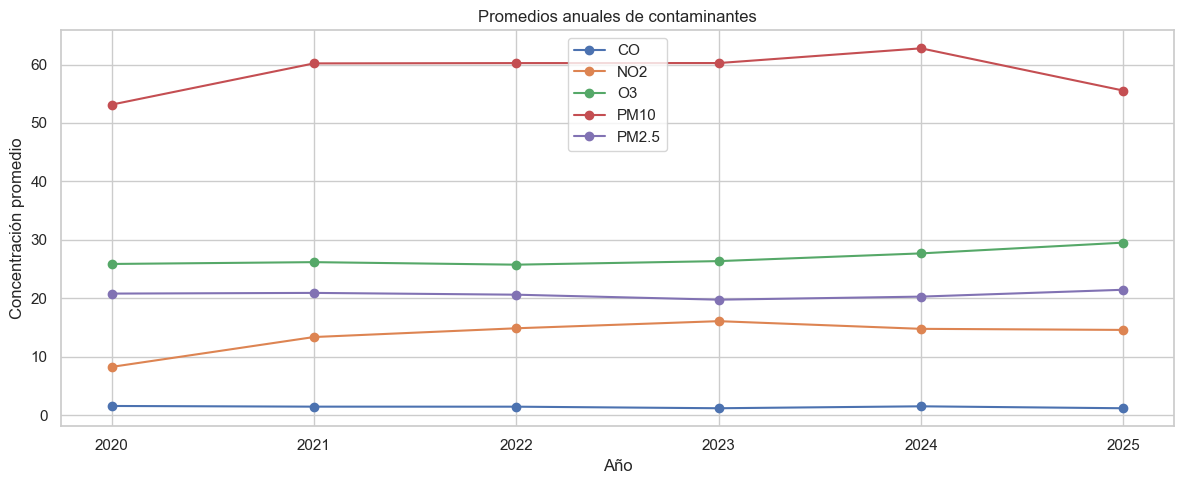

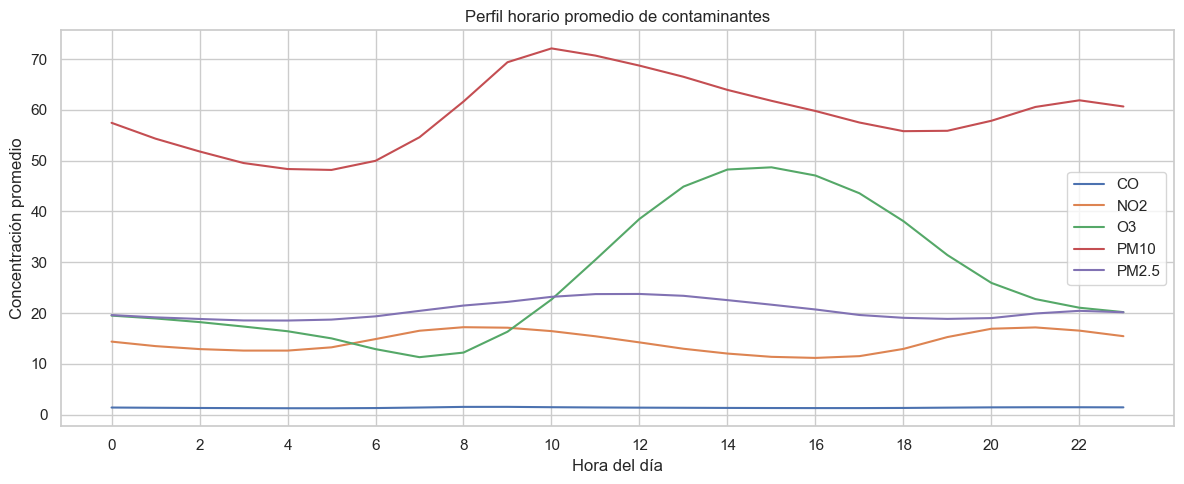

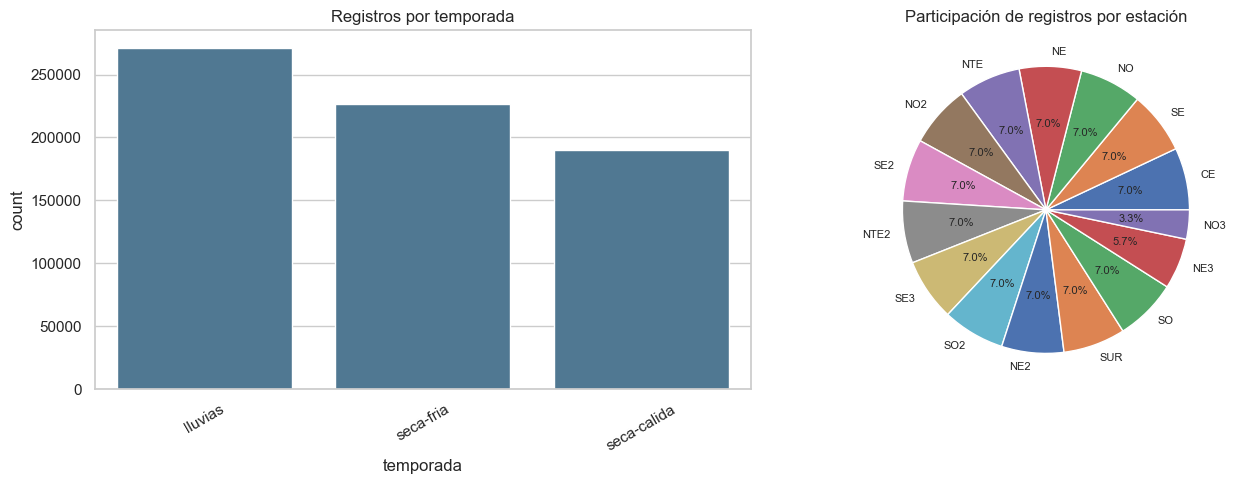

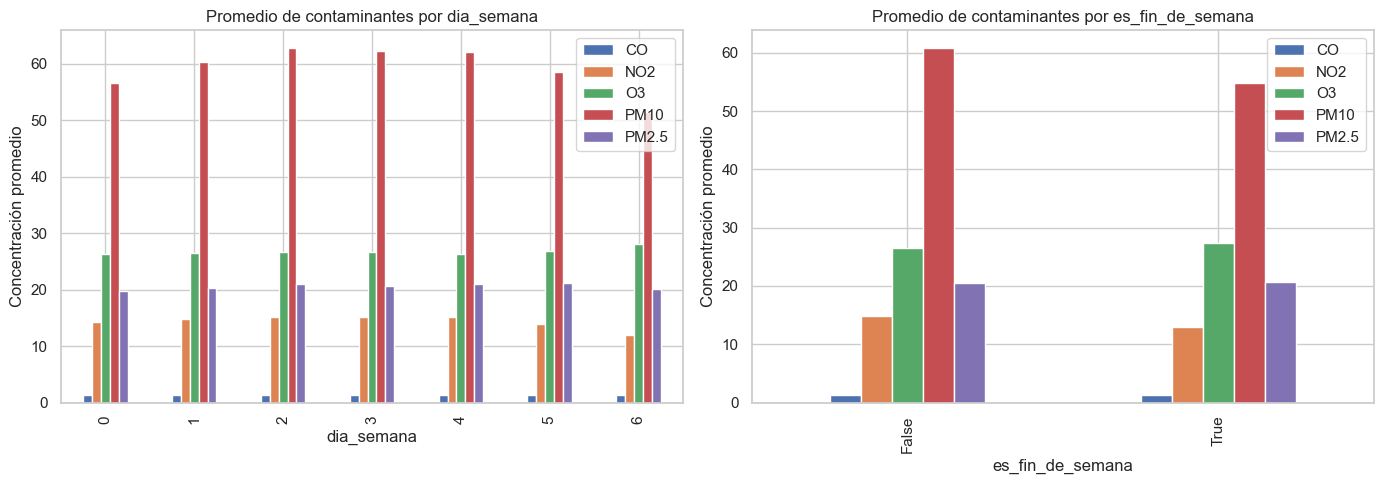

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, variable in zip(axes.flat, contaminantes):
    sns.boxplot(data=df, y=variable, ax=axis, color="#f4a261")
    axis.set_title(f"Boxplot de {variable}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, variable in zip(axes.flat, contaminantes):
    sns.histplot(df[variable].dropna(), bins=50, kde=True, ax=axis, color="#2a9d8f")
    axis.set_title(f"Distribución de {variable}")
    axis.set_xlabel(variable)
plt.tight_layout()
plt.show()

variables_correlacion = contaminantes + meteorologicas
correlacion = df[variables_correlacion].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(correlacion, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlación entre contaminantes y variables meteorológicas")
plt.tight_layout()
plt.show()

promedios_anuales = df.groupby("año_archivo", observed=True)[contaminantes].mean()
promedios_anuales.plot(figsize=(12, 5), marker="o", title="Promedios anuales de contaminantes")
plt.ylabel("Concentración promedio")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

promedios_hora = df.groupby("hora", observed=True)[contaminantes].mean()
promedios_hora.plot(figsize=(12, 5), title="Perfil horario promedio de contaminantes")
plt.ylabel("Concentración promedio")
plt.xlabel("Hora del día")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="temporada", order=df["temporada"].value_counts().index, ax=axes[0], color="#457b9d")
axes[0].set_title("Registros por temporada")
axes[0].tick_params(axis="x", rotation=30)

proporcion_estaciones = df["estación"].value_counts()
axes[1].pie(proporcion_estaciones, labels=proporcion_estaciones.index, autopct="%.1f%%", textprops={"fontsize": 8})
axes[1].set_title("Participación de registros por estación")
plt.tight_layout()
plt.show()

# Exploración adicional de movilidad y meteorología
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for variable, ax in [("dia_semana", axes[0]), ("es_fin_de_semana", axes[1])]:
    datos = df.groupby(variable, observed=True)[contaminantes].mean()
    datos.plot(kind="bar", ax=ax, title=f"Promedio de contaminantes por {variable}")
    ax.set_ylabel("Concentración promedio")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Verificación y preparación de la calidad de los datos

Se revisan valores faltantes, duplicados y consistencia estructural de la base antes de proceder con el análisis. Como la contaminación y la meteorología son variables sensibles al contexto espacial y temporal, es importante confirmar que los datos están completos y comparables entre estaciones.


In [6]:
faltantes = (
    df.isna().sum()
    .rename("nulos")
    .to_frame()
    .assign(porcentaje_nulos=lambda tabla: tabla["nulos"] / len(df) * 100)
    .query("nulos > 0")
    .sort_values("nulos", ascending=False)
)
print("Valores faltantes por variable")
display(faltantes)

print(f"Filas duplicadas exactas: {df.duplicated().sum():,}")
print("Categorías observadas")
for variable in ["estación", "temporada", "PM2.5_nivel_cuartil"]:
    print(f"{variable}: {df[variable].dropna().unique().tolist()}")

# Diagnóstico inicial de la relación entre tráfico y meteorología
promedio_hora_estacion = df.groupby(["hora", "estación"])[["NO2", "CO", "PM2.5", "PM10", "O3"]].mean().reset_index()
print("Promedio de contaminantes por hora y estación:")
display(promedio_hora_estacion.head())


Valores faltantes por variable


,nulos,porcentaje_nulos
PM2.5,131175,19.06
PM2.5_nivel_cuartil,131175,19.06
NO2,109711,15.94
NOX,104318,15.16
NO,96946,14.09
O3,88618,12.88
CO,81505,11.84
SO2,78108,11.35
RH,62568,9.09
WDR,48029,6.98


Filas duplicadas exactas: 0
Categorías observadas
estación: ['CE', 'NE', 'NE2', 'NE3', 'NO', 'NO2', 'NO3', 'NTE', 'NTE2', 'SE', 'SE2', 'SE3', 'SO', 'SO2', 'SUR']
temporada: ['seca-fria', 'seca-calida', 'lluvias']
PM2.5_nivel_cuartil: ['muy_alto', 'medio', 'bajo', 'alto']
Promedio de contaminantes por hora y estación:


,hora,estación,NO2,CO,PM2.5,PM10,O3
0,0,CE,13.02,1.83,21.30,49.52,22.55
1,0,NE,15.10,1.68,22.00,60.75,20.04
2,0,NE2,18.70,1.82,19.48,67.80,15.60
3,0,NE3,10.65,0.49,NaN,40.45,20.77
4,0,NO,14.42,1.78,21.88,49.47,20.18


## Interpretación preliminar orientada al objetivo del proyecto

La siguiente tabla permite identificar cómo cambian los promedios y los picos horarios de contaminantes a lo largo del tiempo. El objetivo es detectar si existen patrones consistentes con mayor actividad vehicular y condiciones meteorológicas de acumulación, sin interpretar estos resultados como causalidad directa.

En particular, se prestará atención a la relación entre:

- horas pico y no pico;
- temporadas secas y de lluvias;
- cambios por estación de monitoreo;
- concentraciones de NO2, CO y PM2.5 frente a variables como temperatura, humedad, viento y precipitación.


In [7]:
resumen_anual = (
    df.groupby("año_archivo", observed=True)[contaminantes]
    .agg(["mean", "median", "max"])
    .round(2)
)
print("Promedios, medianas y máximos por año")
display(resumen_anual)

picos_horarios = (
    df.groupby("hora", observed=True)[contaminantes]
    .quantile(0.90)
    .round(2)
)
print("Percentil 90 por hora, útil para estudiar picos de contaminación")
display(picos_horarios)

# Revisión inicial del patrón por temporada
estadistica_temporada = (
    df.groupby("temporada", observed=True)[contaminantes]
    .mean()
    .round(2)
)
print("Promedio de contaminantes por temporada")
display(estadistica_temporada)


Promedios, medianas y máximos por año


CO                NO2                  O3                PM10  \
            mean median   max  mean median    max  mean median    max  mean   
año_archivo                                                                   
2020        1.55   1.47 17.71  8.24   4.00 188.60 25.86  23.00 159.00 53.14   
2021        1.44   1.25 32.00 13.35  10.30  96.20 26.17  23.00 265.00 60.20   
2022        1.43   1.41  7.42 14.85  11.30 167.80 25.74  22.00 151.80 60.25   
2023        1.16   1.03 14.03 16.07  12.90 158.00 26.35  23.00 171.00 60.26   
2024        1.49   1.20 37.00 14.76  11.90 126.00 27.67  23.00 183.00 62.78   
2025        1.16   0.94  9.79 14.57  11.30 165.10 29.51  26.00 184.00 55.54   

                           PM2.5                
            median     max  mean median    max  
año_archivo                                     
2020         45.00  763.00 20.79  17.43 205.94  
2021         52.00  795.00 20.91  17.36 324.00  
2022         51.00 1001.00 20.60  17.00 442.00  
2023         50.00 1000.00 19.75  16.00 782.00  
2024         54.00  999.00 20.27  16.00 999.00  
2025         45.00  811.00 21.45  18.00 340.25

Percentil 90 por hora, útil para estudiar picos de contaminación


,CO,NO2,O3,PM10,PM2.5
hora,,,,,
0,2.58,31.17,35.00,103.00,37.00
1,2.50,29.51,34.00,99.00,37.00
2,2.43,28.10,33.00,94.00,36.56
3,2.38,27.30,32.00,89.00,35.90
4,2.35,26.50,30.00,86.00,35.69
5,2.33,26.90,29.00,86.00,35.90
6,2.38,28.30,26.00,88.00,36.52
7,2.53,30.20,23.00,96.00,38.01
8,2.74,31.50,23.40,110.00,40.00


Promedio de contaminantes por temporada


,CO,NO2,O3,PM10,PM2.5
temporada,,,,,
lluvias,1.18,11.15,27.37,49.36,16.98
seca-calida,1.39,12.89,31.92,61.26,22.06
seca-fria,1.59,19.52,21.43,68.89,23.57
